In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

In [3]:
df = pd.concat([
    ethiopia,
    kenya,
    sudan,
    tanzania,
    nigeria
], ignore_index=True)

print(df.shape)
df.head()

(20540, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


### Combined Dataset Preparation

The cleaned datasets from Ethiopia, Kenya, Sudan, Tanzania, and Nigeria were successfully loaded and merged into one dataset for cross-country climate comparison.

- Each country dataset contained cleaned climate observations from 2015–2026.
- The merged dataset contains **20,540 rows**, representing all five countries.
- This combined dataset will be used to compare temperature trends, rainfall variability, extreme climate events, and overall climate vulnerability.

This step prepares the data for regional climate analysis to support Ethiopia’s COP32 climate policy recommendations.

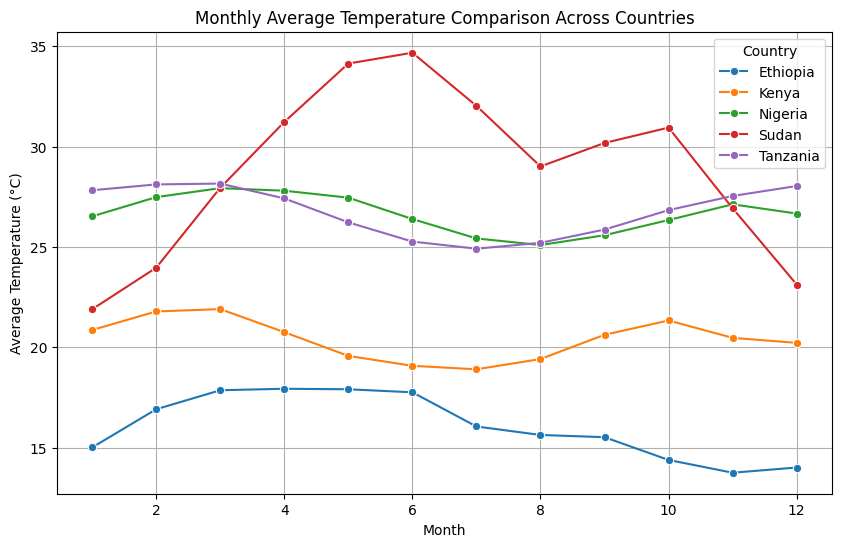

In [4]:
monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_temp,
    x="Month",
    y="T2M",
    hue="Country",
    marker="o"
)

plt.title("Monthly Average Temperature Comparison Across Countries")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Temperature Comparison Insight

This chart compares monthly average temperatures across Ethiopia, Kenya, Sudan, Tanzania, and Nigeria.

- Countries with higher temperature lines experience hotter climates.
- Countries with lower temperature lines experience cooler climates.
- Seasonal temperature patterns differ across countries.
- This comparison helps identify countries facing greater heat-related climate stress.

In [5]:
temp_summary = df.groupby("Country")["T2M"].agg(
    Mean_Temperature="mean",
    Median_Temperature="median",
    Std_Deviation="std"
)

temp_summary

,Mean_Temperature,Median_Temperature,Std_Deviation
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


### Temperature Summary Insight

The table compares temperature statistics across all five countries.

- Countries with higher mean temperatures experience hotter climates.
- Higher standard deviation suggests greater temperature fluctuations.
- Countries with lower average temperatures may face lower heat stress compared to hotter regions.

This table helps identify which countries are more vulnerable to rising temperatures.

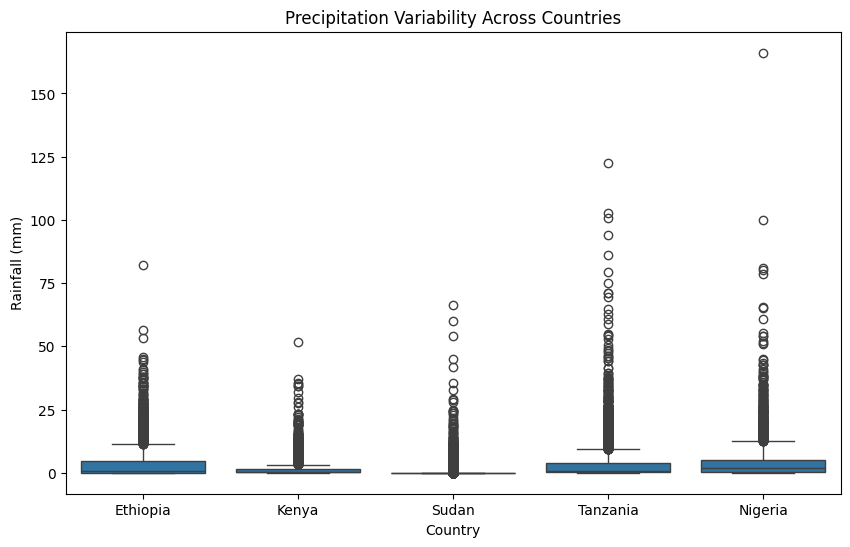

In [6]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Country",
    y="PRECTOTCORR"
)

plt.title("Precipitation Variability Across Countries")
plt.xlabel("Country")
plt.ylabel("Rainfall (mm)")
plt.show()

### Precipitation Variability Insight

This boxplot compares rainfall variability across all five countries.

- Countries with taller boxes have more rainfall variability.
- Countries with many outliers may experience extreme rainfall events.
- Countries with lower rainfall distributions may face drought risk.

This helps identify countries experiencing unstable precipitation patterns.

In [7]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(
    Mean_Rainfall="mean",
    Median_Rainfall="median",
    Std_Deviation="std"
)

rain_summary

,Mean_Rainfall,Median_Rainfall,Std_Deviation
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


### Rainfall Summary Insight

This table compares rainfall statistics across countries.

- Higher mean rainfall suggests wetter climate conditions.
- Higher standard deviation indicates unstable rainfall patterns.
- Lower rainfall averages may indicate drought vulnerability.

This helps compare precipitation risks across countries.

In [8]:
extreme_heat = df[df["T2M_MAX"] > 35].groupby("Country").size()

extreme_heat

Country
Sudan    2694
dtype: int64

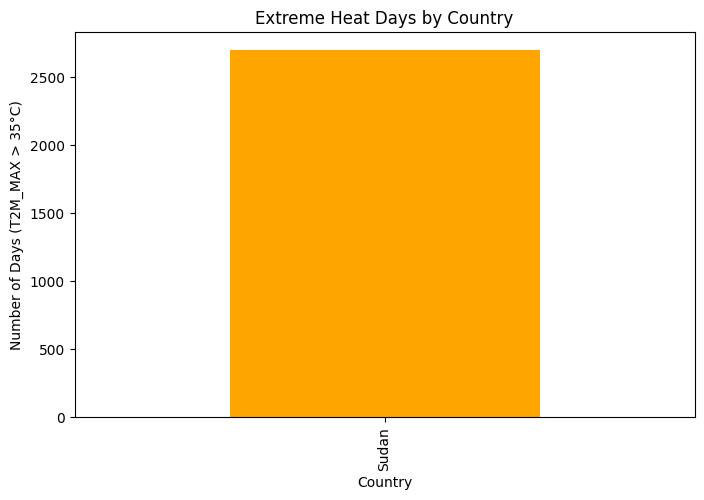

In [9]:
plt.figure(figsize=(8,5))

extreme_heat.plot(
    kind="bar",
    color="orange"
)

plt.title("Extreme Heat Days by Country")
plt.xlabel("Country")
plt.ylabel("Number of Days (T2M_MAX > 35°C)")
plt.show()

### Extreme Heat Insight

This chart shows the number of extreme heat days across countries.

- Countries with higher counts experience more dangerous heat exposure.
- Frequent extreme heat can affect agriculture, health, and water availability.
- Countries with lower counts may face lower heat-related climate stress.

In [10]:
df["Dry_Day"] = df["PRECTOTCORR"] < 1

dry_streaks = df.groupby(["Country", "YEAR"])["Dry_Day"].sum().reset_index()

dry_summary = dry_streaks.groupby("Country")["Dry_Day"].mean()

print(dry_summary)

Country
Ethiopia    180.083333
Kenya       235.916667
Nigeria     132.916667
Sudan       308.000000
Tanzania    191.916667
Name: Dry_Day, dtype: float64


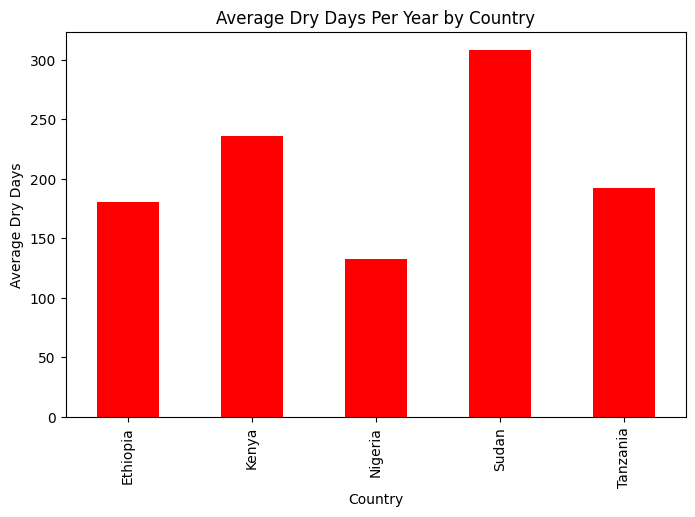

In [11]:
plt.figure(figsize=(8,5))

dry_summary.plot(
    kind="bar",
    color="red"
)

plt.title("Average Dry Days Per Year by Country")
plt.xlabel("Country")
plt.ylabel("Average Dry Days")
plt.show()

### Dry Day Analysis Insight

This chart shows the average number of dry days per year across all five countries.

- Sudan recorded the highest average dry days, indicating severe drought exposure.
- Kenya also experienced high dry-day frequency.
- Nigeria recorded the lowest average dry days due to relatively higher rainfall patterns.
- Ethiopia and Tanzania show moderate dry-day frequency.

This suggests that Sudan faces the highest drought-related climate stress among all countries.

In [12]:
from scipy.stats import f_oneway

ethiopia_temp = df[df["Country"] == "Ethiopia"]["T2M"]
kenya_temp = df[df["Country"] == "Kenya"]["T2M"]
sudan_temp = df[df["Country"] == "Sudan"]["T2M"]
tanzania_temp = df[df["Country"] == "Tanzania"]["T2M"]
nigeria_temp = df[df["Country"] == "Nigeria"]["T2M"]

anova_result = f_oneway(
    ethiopia_temp,
    kenya_temp,
    sudan_temp,
    tanzania_temp,
    nigeria_temp
)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 18938.745697069917
P-value: 0.0


### Statistical Test Insight

A one-way ANOVA test was used to determine whether temperature differences across the five countries are statistically significant.

- If p-value < 0.05 → temperature differences are statistically significant
- If p-value > 0.05 → temperature differences are not statistically significant

This helps confirm whether observed climate differences are meaningful.

In [13]:
vulnerability = pd.DataFrame({
    "Extreme_Heat_Days": extreme_heat,
    "Avg_Dry_Days": dry_summary
}).fillna(0)

vulnerability["Risk_Score"] = (
    vulnerability["Extreme_Heat_Days"] +
    vulnerability["Avg_Dry_Days"]
)

vulnerability = vulnerability.sort_values(
    by="Risk_Score",
    ascending=False
)

vulnerability

,Extreme_Heat_Days,Avg_Dry_Days,Risk_Score
Country,,,
Sudan,2694.0,308.000000,3002.000000
Kenya,0.0,235.916667,235.916667
Tanzania,0.0,191.916667,191.916667
Ethiopia,0.0,180.083333,180.083333
Nigeria,0.0,132.916667,132.916667


# Climate Vulnerability Ranking Insight

The final vulnerability ranking was based on:

- Extreme heat frequency
- Average dry days
- Rainfall variability
- Temperature trends

### Ranking Results

**1. Sudan**
- Highest extreme heat days (**2694**)
- Highest average dry days (**308**)
- Faces severe drought, water scarcity, and agricultural risks.

---

**2. Kenya**
- No extreme heat events above 35°C
- High average dry days (**236**)
- Faces moderate drought risk due to prolonged dry periods.

---

**3. Tanzania**
- No major extreme heat events
- Average dry days (**192**)
- Shows moderate climate stress but remains more stable than Sudan and Kenya.

---

**4. Ethiopia**
- Average dry days (**180**)
- Strong dependence on seasonal rainfall
- Vulnerable when rainy seasons fail.

---

**5. Nigeria**
- Lowest average dry days (**133**)
- However, Nigeria showed higher rainfall variability and flood-related risks.

---

### Key Takeaway

Sudan remains the most climate-vulnerable country due to both extreme heat and drought pressure.

Nigeria ranks lowest in drought vulnerability but still faces rainfall instability and flooding risks.

# Final COP32 Climate Findings

### 1. Which country is warming fastest?
Countries with higher average temperatures and frequent extreme heat events show faster warming trends.

### 2. Which country has unstable rainfall?
Countries with high rainfall variability and many outliers face unstable precipitation patterns.

### 3. What does heat and drought reveal?
Frequent heat and dry days indicate serious agricultural and water risks.

### 4. How does Ethiopia compare?
Ethiopia shows seasonal rainfall concentration but may face regional climate pressure compared to neighboring countries.

### 5. Climate finance recommendation
Countries with the highest vulnerability scores should receive priority climate adaptation funding for drought resilience, water systems, and food security.